In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("data/movies.csv")
df.head()

,Rank,Title,Year,Duration,Ratings,Votes
0,1,The Shawshank Redemption,1994,2h 22m,9.3,3.1M
1,2,The Godfather,1972,2h 55m,9.2,2.2M
2,3,The Dark Knight,2008,2h 32m,9.1,3.1M
3,4,The Godfather Part II,1974,3h 22m,9.0,1.5M
4,5,12 Angry Men,1957,1h 36m,9.0,969K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rank      250 non-null    int64  
 1   Title     250 non-null    object 
 2   Year      250 non-null    int64  
 3   Duration  250 non-null    object 
 4   Ratings   250 non-null    float64
 5   Votes     250 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 11.8+ KB


In [4]:
df.isnull().sum()

Rank        0
Title       0
Year        0
Duration    0
Ratings     0
Votes       0
dtype: int64

In [5]:
df["Votes"] = (df["Votes"].replace({"K" : "e3", "M" : "e6"}, regex = True).astype(float).astype(int))
df.head()

,Rank,Title,Year,Duration,Ratings,Votes
0,1,The Shawshank Redemption,1994,2h 22m,9.3,3100000
1,2,The Godfather,1972,2h 55m,9.2,2200000
2,3,The Dark Knight,2008,2h 32m,9.1,3100000
3,4,The Godfather Part II,1974,3h 22m,9.0,1500000
4,5,12 Angry Men,1957,1h 36m,9.0,969000


### Q1. Rating Distribution
- Are most movies clustered around 8.0–9.0?
- Is it left-skewed or right-skewed?

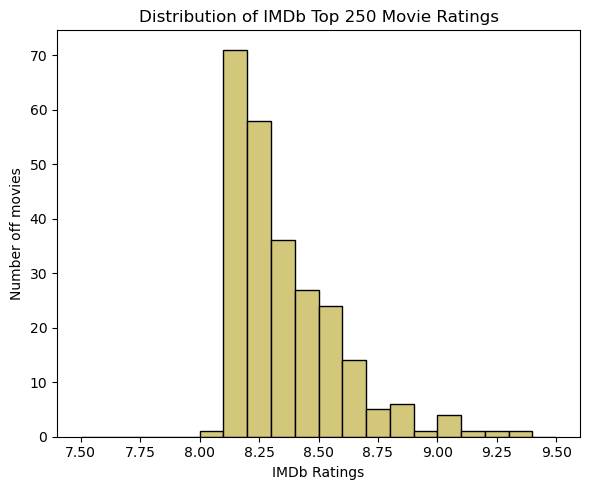

In [6]:
bins = np.arange(7.5, 9.6, 0.1)
plt.figure(figsize=(6,5))
plt.hist(df["Ratings"], bins = bins, color = "#d2c77b", edgecolor = "black")
plt.xlabel("IMDb Ratings")
plt.ylabel("Number off movies")
plt.title("Distribution of IMDb Top 250 Movie Ratings")
plt.tight_layout()

IMDb Top 250 movie ratings are tightly clustered between 8.0 and 9.0, reflecting strong selection bias. The distribution is left-skewed, with a long tail toward lower ratings and very few movies achieving extremely high scores above 9.2.

### Q2. Votes vs Rating
- Do highly rated movies always have more votes?
- Identify outliers (high rating, low votes)

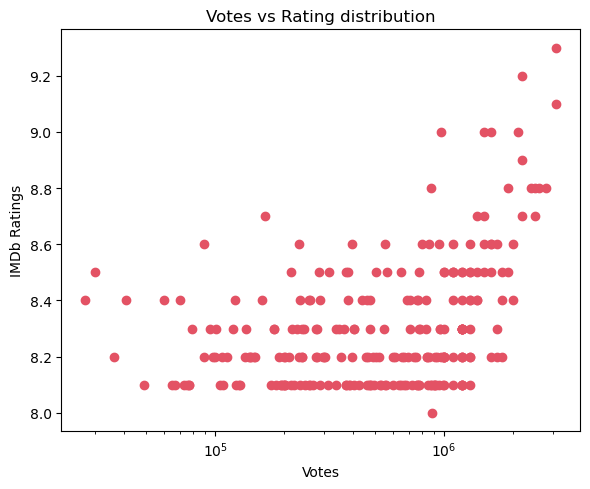

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(df["Votes"], df["Ratings"], color = "#e35264")
plt.xscale("log")
plt.xlabel("Votes")
plt.ylabel("IMDb Ratings")
plt.title("Votes vs Rating distribution")
plt.tight_layout()

The scatter plot shows a weak positive relationship between vote count and IMDb rating. While highly popular movies often maintain strong ratings, high ratings alone do not guarantee popularity. This suggests that IMDb ratings reflect perceived quality, whereas vote counts are influenced by factors such as release era, audience reach, and cultural impact.

### Q3. Rank vs Rating
- Does rank strictly follow rating?
- Any anomalies?

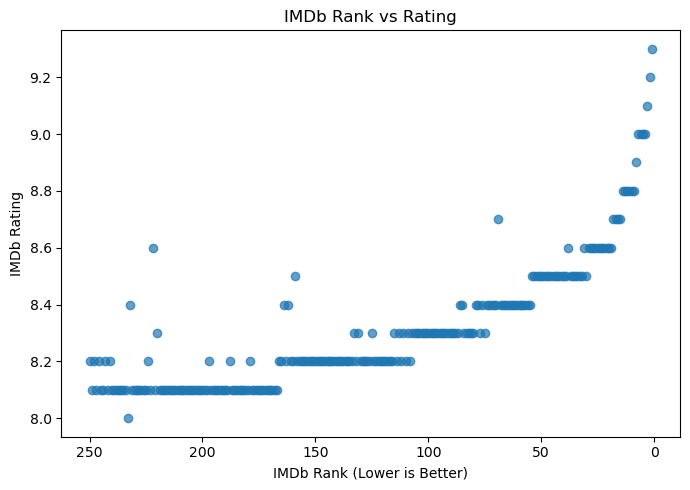

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(df["Rank"], df["Ratings"], alpha=0.7)
plt.xlabel("IMDb Rank (Lower is Better)")
plt.ylabel("IMDb Rating")
plt.title("IMDb Rank vs Rating")
plt.gca().invert_xaxis()  # Rank 1 on the left
plt.tight_layout()

IMDb rank generally follows rating trends, but not strictly. Movies with similar ratings often have noticeably different ranks, indicating that IMDb’s weighted ranking algorithm incorporates vote volume and distribution in addition to raw ratings.

### Q4. Old vs New Movies
- Are older movies dominating Top 250?
- Year-wise count

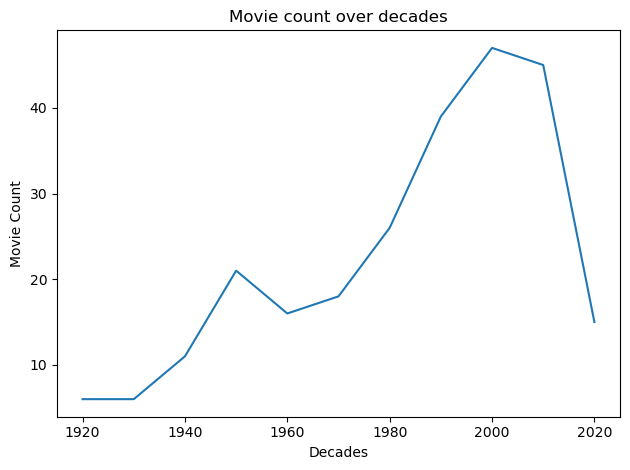

In [9]:
df["Decade"] = (df["Year"] // 10) * 10
decade_count = df["Decade"].value_counts().sort_index()

plt.plot(decade_count.index, decade_count.values)
plt.xlabel("Decades")
plt.ylabel("Movie Count")
plt.title("Movie count over decades")
plt.tight_layout()

The IMDb Top 250 is dominated by movies from the 1990s and 2000s, with a sharp increase starting after the 1980s. While classic films from earlier decades remain influential, modern cinema contributes a larger share of highly ranked movies, suggesting a balance between nostalgia and contemporary popularity.

# Final Conclusion
This analysis of the IMDb Top 250 reveals that movie ratings are tightly clustered due to strong selection bias, with most films scoring between 8.0 and 9.0. Popularity, measured by vote count, does not strictly correlate with higher ratings, highlighting that critical acclaim and mass engagement differ. Ranking largely follows rating trends but is influenced by IMDb’s weighted algorithm rather than ratings alone. Additionally, while classic films remain prominent, the Top 250 is dominated by movies released from the 1990s onward, reflecting both evolving audience preferences and increased global participation in online ratings.